# Regression

This notebook reviews some classical algorithms to perform regression on data.

## SVR

Support Vector Regression [1] is an optimization problem based on the same principles as SVM, but aimed for regression problems. The basic SVR formulation is:

\begin{equation*}
\begin{alignat*}{2}
&\!\min_{f \in \mathcal{H},b \in \mathbb{R}^N} &\qquad&  C \sum\limits_{i=1}^N \max(0, y_i - \epsilon - (f(x_i) + b)) + \max(0, f(x_i) + b - (y_i + \epsilon)) + \frac{1}{2}||f||_{\mathcal{H}}^2,\\
\end{alignat*}
\end{equation*}
where $C$ and $\epsilon$ are respectively the regularization and tube width parameters. They are chosen by the operator.

After the introduction of slack variables $\xi_i, \xi_i^\star$ to have a soft-margin and make the problem feasible whatever the points configuration, the problem is trivially equivalent to:

\begin{equation*}
\begin{alignat*}{3}
&\!\min_{f \in \mathcal{H},b \in \mathbb{R},\xi, \xi^\star \in \mathbb{R}^N} &\qquad& C\sum_{i = 1}^N \xi_i + \xi_i^\star + \frac{1}{2}||f||_{\mathcal{H}}^2\\
&\text{subject to} &      & f(x_i) + b - y_i \leq \xi_i + \epsilon \quad \forall i \in \{1, \cdots, N\} & \text{(lower bound)}\\
&                  &      & y_i - f(x_i) - b \leq \xi_i^\star + \epsilon \quad \forall i \in \{1, \cdots, N\} & \text{(upper bound)}\\
&                  &      & \xi_i \geq 0, \xi_i^\star \geq 0 \quad \forall i \in \{1, \cdots, N\} \\
\end{alignat*}
\end{equation*}

The first constraint ensures that the data points is not too far from below, and the second constraint that it is not to far from above. The representer theorem can be applied, let $f(x)=\sum\limits_{i=1}^N \beta_i K(x_i,x) + b$. After pluging it, 

The dual problem is [1,2]:
\begin{equation*}
\begin{alignat*}{2}
&\!\min_{\alpha, \alpha^\star \in \mathbb{R}^N} &\qquad& (\alpha - \alpha^\star)^\top K(\alpha - \alpha^\star) + \epsilon e^\top (\alpha + \alpha^\star) - y^\top (\alpha - \alpha^\star)\\
&\text{subject to} &      & e^\top(\alpha - \alpha^\star) = 0 \\
&                  &      & \alpha_i \geq 0; \alpha_i \leq C\quad \forall i \in \{1, \cdots, N\}, \\
&                  &      & \alpha_i^\star \geq 0; \alpha_i^\star \leq C\quad \forall i \in \{1, \cdots, N\}, \\
\end{alignat*}
\end{equation*}
with $e = (1, \cdots, 1)^\top$ and $\alpha, \alpha^\star$ the Lagrange multiplier of the two first sets of constraints in primal formulation. It can also be solved quite easily via a quadratic solver. $K$ is the Gram matrix: $(K_{i,j})_{i, j \in \{1, \cdots, N\}}=(K(x_i, x_j))_{i, j \in \{1, \cdots, N\}}$. One can show that the expansion's coefficients are related to Lagrange's multipliers: $\beta_i = \alpha_i-\alpha^\star_i$ [2]. Also $b$ is chosen as: $b=\max\limits_i \{-\epsilon + y_i -f(x_i) | \alpha_i<C, \alpha_i^\star >0\}=\min\limits_i \{-\epsilon + y_i -f(x_i) | \alpha_i>0, \alpha_i^\star <C\}$. And if $\alpha_i \in (0,C)$, then $b=-\epsilon + y_i -f(x_i)=y_i - \epsilon - \sum\limits_{j=1}^N (\alpha_i - \alpha_i^\star)K(x, x_i)$.

For resolution, I'll use the same quadratic solver as for PCA, i.e., *Sequential Least Square Quadratic Programming* (SLSQP), one of the only algorithm I know that can handle both equality and inequality constraints.


[1] https://alex.smola.org/papers/2004/SmoSch04.pdf

[2] https://proceedings.neurips.cc/paper_files/paper/1996/file/d38901788c533e8286cb6400b40b386d-Paper.pdf

In [1]:
from sklearn.base import RegressorMixin, BaseEstimator
import numpy as np
from scipy.optimize import fmin_slsqp
import matplotlib.pyplot as plt

def Linear(gamma: float=None, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        #Vectorize scalar product
        if len(x.shape) == len(y.shape) and len(x.shape) > 1:
            if on_diagonal:
                return np.einsum('ij, ij -> i', x, y)
            return np.einsum('ij, kj -> ik', x, y)
        return x @ y.T
    return kernel

def RBF(gamma: float = 1, c: float=None):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        if len(x.shape)==1 or len(y.shape)==1:
            on_diagonal=True
        if on_diagonal:
            expo=-(np.sum((x - y)**2, axis = -1))/(2*gamma) #Sum along data axis
        else:
            expo = -(np.sum((x[:,None,:] - y[None,:,:])**2, axis = -1))/(2*gamma) #Sum along data dimension
        return np.exp(expo)
    return kernel

def poly(gamma: int, c:float=1):
    assert type(gamma)==int, "Power parameter should be an integer."
    lin=Linear()
    def kernel(x, y, on_diagonal: bool=False):
        return np.pow((c + lin(x, y, on_diagonal)), gamma)
    return kernel

def sigmoid(gamma: float=1, c: float=1):
    lin=Linear()
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        return np.tanh(gamma*lin(x, y, on_diagonal) + c)
    return kernel

dict_kernel=dict({"linear": Linear, "gaussian": RBF, "polynomial": poly})

class SVR(RegressorMixin, BaseEstimator):
    def __init__(self, epsilon: float, C:float, kernel: str, gamma: float=1, c: float=None):
        self.epsilon=epsilon
        self.C=C
        assert C > 0, "C should be positive."
        self.kernel=dict_kernel.get(kernel)(gamma, c)
        self.is_fitted=False
        self.X=None

    def fit(self, X: np.ndarray, y: np.ndarray):
        N=len(X)
        self.X=X
        e=np.ones(N)
        assert len(X)==len(y), "X and y should have the same number of elements."
        K=self.kernel(X, X)
        alpha=np.ones(N)*self.C/2
        alpha_star=np.ones(N)*self.C/2
        Alpha_c=np.concatenate((alpha, alpha_star), axis=0)

        def loss(Alpha_c: np.ndarray):
            alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
            return (alpha-alpha_star)@K@(alpha-alpha_star) + self.epsilon * e @ (alpha + alpha_star) - (alpha-alpha_star)@y

        def grad_loss(Alpha_c: np.ndarray):
            alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
            part_1=K@(alpha - alpha_star) + self.epsilon*e - y
            part_2=K@(alpha_star - alpha) + self.epsilon*e + y
            return np.concatenate((part_1[None,...], part_2[None,...]), axis=1)

        def eqcons(Alpha_c: np.ndarray):
            alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
            return e@(alpha-alpha_star)

        def grad_eqcons(Alpha_c: np.ndarray):
            return np.concatenate((e[None,...], -e[None,...]), axis=1)

        def ieqcons(Alpha_c: np.ndarray):
            alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
            return np.concatenate((alpha, self.C - alpha, alpha_star, self.C - alpha_star), axis=0)

        def grad_ieqcons(Alpha_c: np.ndarray):
            bloc1=np.concatenate((np.eye(N), np.zeros((N,N))), axis=1)
            bloc2=np.concatenate((np.zeros((N,N)), np.eye(N)), axis=1)
            return np.concatenate((bloc1, -bloc1, bloc2, -bloc2), axis=0)

        Alpha_c=fmin_slsqp(func=loss, x0=Alpha_c, f_eqcons=eqcons, f_ieqcons=ieqcons, \
            fprime=grad_loss, fprime_eqcons=grad_eqcons, fprime_ieqcons=grad_ieqcons)

        alpha, alpha_star=Alpha_c[:N], Alpha_c[N:]
        idx=np.where(alpha < 1e-9)[0]
        alpha[idx]=0
        idx=np.where(self.C - alpha < 1e-9)[0]
        alpha[idx]=self.C

        idx=np.where(((alpha>0)&(alpha<self.C)))[0]

        if len(idx)==0:
            idx=np.where(alpha_star > 1e-9 and alpha < self.C)[0]
        idx=idx[0]

        self.beta=alpha-alpha_star
        self.b=y[idx] - self.epsilon - self.kernel(X[idx], X) @ self.beta

        self.is_fitted=True

    def predict(self, X_test: np.ndarray):
        return self.kernel(X_test, self.X)@self.beta + self.b

Optimization terminated successfully    (Exit mode 0)
            Current function value: -59.32270046851741
            Iterations: 13
            Function evaluations: 26
            Gradient evaluations: 13
Optimization terminated successfully    (Exit mode 0)
            Current function value: -59.522878367718285
            Iterations: 20
            Function evaluations: 38
            Gradient evaluations: 20


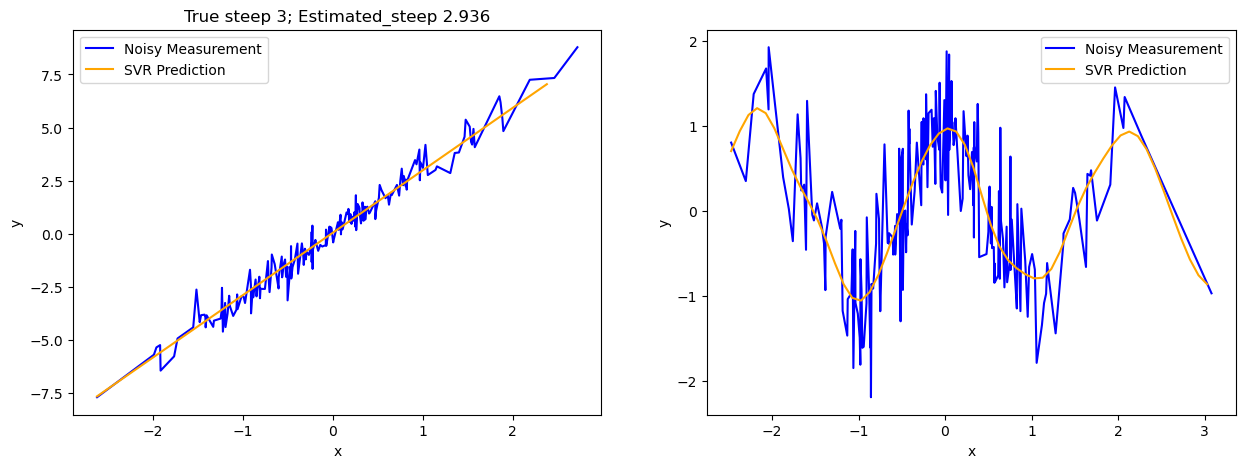

In [4]:
np.random.seed(42)
fig=plt.figure(figsize=(15,5))


axes=fig.add_subplot(121)

n_samples, n_features = 200, 1
X = np.random.randn(n_samples, n_features)
true_coef = 3

X.sort(axis=0)
y = X*true_coef
# Add some noise
y += .5*np.random.normal(size=(n_samples, 1))
y=y.squeeze()
plt.plot(X, y, c='blue', label='Noisy Measurement')

X_test=np.arange(np.min(X), np.max(X), step=.5)[...,None]
svr=SVR(epsilon=.1, C=1, kernel="linear")
svr.fit(X,y)
y_test=svr.predict(X_test)
estimated_steep=(y_test[-1] - y_test[0])/(X_test[-1].item() - X_test[0].item())

axes.plot(X_test, y_test, c='orange', label="SVR Prediction")
axes.set_title(f"True steep {true_coef}; Estimated_steep {estimated_steep:.3f}")
axes.set_xlabel("x")
axes.set_ylabel("y")
plt.legend()

axes=fig.add_subplot(122)

X = np.random.randn(n_samples, n_features)

X.sort(axis=0)
y = np.cos(true_coef*X)
# Add some noise
y += .5*np.random.normal(size=(n_samples, 1))
y=y.squeeze()
plt.plot(X, y, c='blue', label='Noisy Measurement')

X_test=np.arange(np.min(X), np.max(X), step=.1)[...,None]
svr=SVR(epsilon=.1, C=1, kernel="gaussian", gamma=.1)
svr.fit(X,y)
y_test=svr.predict(X_test)
estimated_steep=(y_test[-1] - y_test[0])/(X_test[-1].item() - X_test[0].item())

axes.plot(X_test, y_test, c='orange', label="SVR Prediction")
axes.set_xlabel("x")
axes.set_ylabel("y")
plt.legend()
plt.show()


## Nadaraya-Watson estimator

Nadaraya-Watson estimator aims to approach $m(X)=\mathbb{E}[Y|X]$ by approximating the conditional probability $\mathbb{P}[Y|X]$ with a kernel $K$. It belongs to the class of non-parametric method, but you still need to specify the bandwidth hyperparameter $h$ though. The paremetrized kernel is defined by $K_h(x)=\frac1h K(\frac{x}{h})$. Also, the kernel should verify $\int_{\mathbb{R}} xK(x)dx=0$ and $\int_{\mathbb{R}} K(x)dx=1$. Let $X=(x_1, \cdots, x_N)$ and $Y=(y_1, \cdots, y_N)$ a training dataset sampled from $\mathbb{P}_{X,Y}$. Starting from:
$$
f_{Y|X=x}(y)=\frac{f_{Y,X}(y,x)}{f_{X}(x)}
$$
and introducing the approximation $\hat f_{X,Y}=\frac1N \sum\limits_{i=1}^N K_h(x-x_i)K_h(y-y_i)$, $\hat f_X=\frac1N \sum\limits_{i=1}^N K_h(x-x_i)$.

The computation is quite straightforward. Plugging this expressions into $m(x)=\displaystyle\int_{\mathcal{Y}} \frac{yf_{Y,X}(y,x)}{f_X(x)} dy$ yields:
$$
\hat m(x)=\frac{\sum\limits_{i=1}^N y_iK_h(x-x_i)}{\sum\limits_{i=1}^NK_h(x-x_i)}.
$$

In [6]:
from sklearn.base import RegressorMixin, BaseEstimator
import numpy as np
import matplotlib.pyplot as plt

def RBF(gamma: float = 1, h: float=1):
    def kernel(x: np.ndarray, y: np.ndarray, on_diagonal: bool=False):
        d=x.shape[-1]
        if len(x.shape)==1 or len(y.shape)==1:
            on_diagonal=True
        if on_diagonal:
            expo=-(np.sum((x/h - y/h)**2, axis = -1))/(2*gamma) #Sum along data axis
        else:
            expo = -(np.sum((x[:,None,:]/h - y[None,:,:]/h)**2, axis = -1))/(2*gamma) #Sum along data dimension
        return np.exp(expo)/(2*np.pi*gamma)**(d/2)/h
    return kernel


class Nadaraya_Watson(RegressorMixin, BaseEstimator):
    def __init__(self, h: float, kernel: str='gaussian', gamma: float=1):
        assert h>0, "The bandwidth h should be positive"
        self.h=h
        self.kernel=RBF(gamma, h)
        self.X=None
        self.y=None

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.X=X
        self.y=y

    def predict(self, X_test: np.ndarray):
        K=self.kernel(X_test, self.X)
        return K@self.y/np.sum(K, axis=-1)

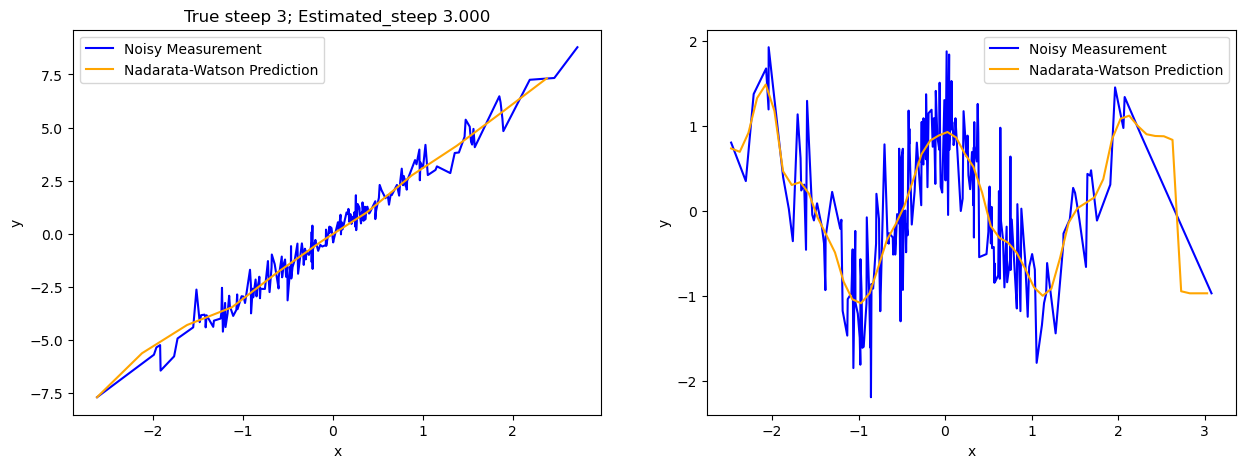

In [ ]:
np.random.seed(42)
fig=plt.figure(figsize=(15,5))


axes=fig.add_subplot(121)

n_samples, n_features = 200, 1
X = np.random.randn(n_samples, n_features)
true_coef = 3

X.sort(axis=0)
y = X*true_coef
# Add some noise
y += .5*np.random.normal(size=(n_samples, 1))
y=y.squeeze()
plt.plot(X, y, c='blue', label='Noisy Measurement')

X_test=np.arange(np.min(X), np.max(X), step=.5)[...,None]
svr=Nadaraya_Watson(h=1, gamma=.01)
svr.fit(X,y)
y_test=svr.predict(X_test)
estimated_steep=(y_test[-1] - y_test[0])/(X_test[-1].item() - X_test[0].item())

axes.plot(X_test, y_test, c='orange', label="Nadarata-Watson Prediction")
axes.set_title(f"True steep {true_coef}; Estimated_steep {estimated_steep:.3f}")
axes.set_xlabel("x")
axes.set_ylabel("y")
plt.legend()

axes=fig.add_subplot(122)

X = np.random.randn(n_samples, n_features)

X.sort(axis=0)
y = np.cos(true_coef*X)
# Add some noise
y += .5*np.random.normal(size=(n_samples, 1))
y=y.squeeze()
plt.plot(X, y, c='blue', label='Noisy Measurement')

X_test=np.arange(np.min(X), np.max(X), step=.1)[...,None]
svr=Nadaraya_Watson(h=1, gamma=.01)
svr.fit(X,y)
y_test=svr.predict(X_test)
estimated_steep=(y_test[-1] - y_test[0])/(X_test[-1].item() - X_test[0].item())

axes.plot(X_test, y_test, c='orange', label="Nadarata-Watson Prediction")
axes.set_xlabel("x")
axes.set_ylabel("y")
plt.legend()
plt.show()

## Isotonic regression

Let $\mathcal{D}=(x_i, y_i)_{i \in \{1, \cdots, N\}}$ a dataset in $\mathbb{R}^d \times \mathbb{R}$. One assume the dataset sorted, i.e. $x_i \leq x_j \implies i \leq j$.

Isotonic regression aims to find a monotonic function $f$ satisfying as well as possible $f(x_i) \approx y_i$. The strategy of resolution is the following:
 > 1 Solve the quadratic programming with linear constraints: 
 $$
 \begin{array}{cc}
 \min\limits_{\hat y_i} & \sum\limits_{i=1}^N w_i (\hat y_i - y_i)^2, \\
 \text{s.t} & y_i \leq y_j \, \text{if} \, x_i \leq x_j.
 \end{array}
 $$
 where $(w_i)_{i \in \{1, \cdots, N\}}$ is a set of positive weights, most often $\forall i \in \{1, \cdots, N\}, w_i=1$. Note that the constraint implies both that $x_i$ and $x_j$ can be compared and that $x_i$ and smaller than $x_j$. This is important on partially ordered set, like $\mathbb{R}^d$, with $d>1$. If $d=1$, it can be written in the form:
 $$
 \begin{array}{cc}
 \min\limits_{\hat Y \in \mathbb{R}^N} & \sum\limits_{i=1}^N  (\hat Y - Y)^\top W(\hat Y - Y), \\
 \text{s.t} & HY \leq 0,
 \end{array}
 $$
 where $H=\begin{bmatrix} 1 & -1 & 0 & 0 &\cdots & 0 & 0\\ 0 & 1 & -1 & 0 & \cdots & 0 & 0\\ 0 & 0 & 1 & -1 & \cdots & 0 & 0\\ \vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\ 0 & 0 & 0 & 0 & \cdots &1 & -1\end{bmatrix} \in \mathbb{R}^{(N-1) \times N}$ and $W=\text{diag}(w_1, \cdots, w_N)$.
 > 2 Use the $\hat y_i$ as landmarks to build a function, connecting points with a simple linear interpolation. More formally, if $d=1$,
  let 
  $$
  f(x)=
  \begin{cases}
    \hat y_1 \, \text{if} \, x \leq x_1, \\
    \hat y_i + \frac{x - x_i}{x_{i+1} - x_i}(\hat y_{i+1} - \hat y_i) \, \text{if} \, x_i\leq x \leq x_{i+1},\\
    \hat y_N \, \text{if} \, x \geq x_N.
  \end{cases}
  $$

The dual problem is:
$$
\begin{array}{cc}
\max\limits_{\alpha \in \mathbb{R}_+^{n-1}} -\frac12 (A^\top\alpha - Wy)W^{-1}(A^\top\alpha - Wy) + \frac12 y^\top W y.
\end{array}
$$

It is a quadratic programming (QP) under positivity constrains, making it directly more suitable to numerical resolution.
The KKT conditions are:
$$
\begin{array}{cc}
W(\hat y^\star - y) + A^\top \alpha=0 & \text{(Stationarity)}\\
\langle \alpha^\star, A\hat y^\star \rangle=0 & \text{(complementary slackness)}\\
\alpha^\star \geq 0 & \text{(dual feasibility)}\\
A\hat y^\star\leq 0 & \text{(primal feasability)}.
\end{array}
$$

The two first conditions respectively yields $\forall i \in \{1, \cdots, n\}$,
$w_i(\hat y_i^\star - y_i) + \alpha_i^\star - \alpha_{i-1}^\star=0$ and $\alpha^\star_i (\hat y^\star_i - \hat y^\star_{i+1})_i=0$, where $\alpha_0^\star=\alpha_n^\star=0$. Complementary slackness directly states that $\hat y^\star_i < \hat y^\star_{i+1} \implies \alpha_i^\star = 0$. Take $(B_i)_{i \in \{1, \cdots, M\}}$ a partition of $\{1, \cdots, n\}$, where each $B_i$ is an interval of the form $[\underbar b_i, \bar b_i]$. $\hat y$ is assumed constant on each block $B_i$ and to be strictly increasing with the block's index $i$. It follows immediately that $\forall i \in \{1, \cdots, n\}$, $\alpha_{\underbar b_i - 1}^\star = \alpha_{\bar b_i}^\star=0$. Summing over a block $B_i$ the stationarity condition yields $\sum\limits_{j \in B_i} w_j (\hat y_j^\star - y_j) + \alpha_{\bar b_i}^\star - \alpha_{\underbar b_i - 1}^\star = \sum\limits_{j \in B_i} w_j (\hat y_j^\star - y_j) = 0$ yielding $\forall j \in B_i, \hat y_j^\star = \displaystyle\frac{\sum\limits_{j \in B_i}w_j y_j}{\sum\limits_{j \in B_i}w_j}$.

To solve this problem, the common method is the Pool Adjacent Violators Algorithm (PAVA) [1] [2].
The strategy is to merge adjacent blocks together when necessary, that is, when a constraint is violated. First, each input $i$ starts as its own block.


[1] https://www.stat.umn.edu/geyer/8054/notes/isotonic.pdf

[2] https://josephsalmon.eu/blog/isotonic/ 

In [138]:
def PAVA(y: np.ndarray, w: np.ndarray=None):
    if w is None:
        w=np.ones(len(y))
    if not isinstance(y, np.ndarray):
        y=np.array(y)
    hat_y=y.copy()
    assert len(w)==len(y), "y and w should have the same size."
    N=len(y)
    B=[[i] for i in range(N)]
    i=1
    while i < N:
        if hat_y[i] < hat_y[i-1]:
            hat_y[i]= (w[i]*hat_y[i] + w[i-1]*hat_y[i-1])/(w[i] + w[i-1])
            w[i] += w[i-1]
            B[i] += B[i-1]
            B.pop(i-1); w=np.delete(w, i-1); hat_y=np.delete(hat_y, i-1)
            N -= 1
            if i > 1:
                i -= 1
        else:
            i += 1
    sol=np.zeros_like(y)
    for i, block in enumerate(B):
        sol[block]=hat_y[i]
    return sol

def linear_interpolation(X: np.ndarray, y: np.ndarray):
    def f(x):
        idx=np.argmin(np.abs(x-X), axis=-1)
        if x <= X[idx]:
            idx -= 1
        idx, idx_next=idx, idx+1
        return y[idx] + (x-X[idx])/(X[idx_next] - X[idx])*(y[idx_next] - y[idx])
    return f

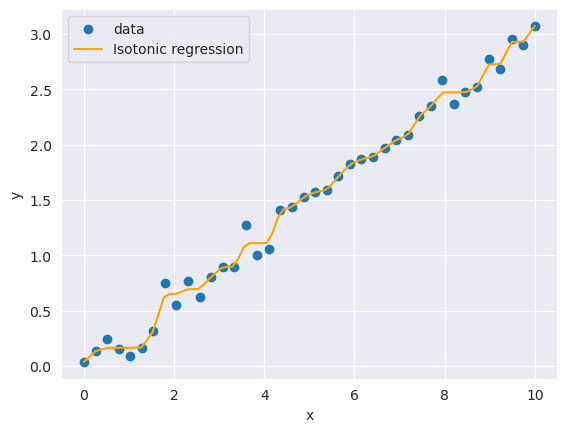

In [141]:
X=np.linspace(0,10,40)
y=X*.3 + np.random.randn(40)*.1

plt.scatter(X, y, label="data")

hat_y=PAVA(y)

X_test=np.linspace(0, 10, 80)
f=linear_interpolation(X, hat_y)
f_vect=np.vectorize(f, signature='(n) -> (n)')

plt.plot(X_test, f_vect(X_test[...,None]), c="orange", label="Isotonic regression")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Kriging

I use here [GPy](https://gpy.readthedocs.io/en/devel/index.html) library, but many other exist. The API reference is not great, I use this only for illustration purpose. **Therefore, unlike others, this section is not from scratch**. A lot of packages that derive Gaussian Processes can be found in python, such as [scikit-learn](https://scikit-learn.org/stable/), [openTURNS](http://www.openturns.org/), [GPflow](https://github.com/GPflow/GPflow), [SMT](https://github.com/SMTorg/smt=), [GPyTorch](https://gpytorch.ai/), etc.

**The idea behind kriging, also known as kernel Bayesian linear regression, is to select a prior distribution over the set of admissible functions in order to make an estimate.** The prior is not based on the distribution of certain parameters, but on entire functions of $\mathbb{R}^d$. Due to the tractability of the calculations, kriging assumes Gaussian processes as the prior. According to Kolmogorov's extension theorem, a stochastic process is uniquely determined by the law of its finite dimensional joint laws. Let $K: \mathcal{X}\times \mathcal{X} \rightarrow \mathbb{R}$ a valid positive definite kernel and $m: \mathcal{X} \rightarrow \mathbb{R}$ a continuous real-valued function. Then by definition, $X \sim \mathcal{GP}(m, K)$ if $\forall N \in \mathbb{N}, \forall (t_1, \cdots, t_N) \in \mathcal{X}^N, (X(t_1), \cdots, X(t_N)) \sim \mathcal{N}\bigg(\begin{bmatrix} m(t_1)\\ m(t_2) \\ \vdots \\ m(t_N)\end{bmatrix}, \begin{bmatrix} K(t_1, t_1) & K(t_1, t_2) & \cdots & K(t_1, t_{N-1}) &K(t_1, t_N)\\ K(t_2, t_1) & K(t_2, t_2)& \cdots & K(t_2, t_{N-1}) & K(t_2, t_N) \\ \vdots & \vdots & \ddots & \vdots & \vdots\\ K(t_N, t_1) & K(t_N, t_2) & \cdots & K(t_N, t_{N-1}) & K(t_N, t_N)\end{bmatrix}\bigg)$.

A common setup is that model's outputs are corrupted with noise, usually assumed gaussian. It writes as $Y=X + \sigma Z$, where $Z \sim \mathcal{N}(0, I)$. It is common knowledge that the sum of two gaussians is a gaussian, yielding $Y\sim \mathcal{GP}(m, K+\sigma^2 \text{Id})$.

$m$ and $K$ are usually parameterized, so one will rather note $m_\beta$ and $K_\theta$ from now on. $m_\beta$ is often of the form: $m_\beta= \sum\limits_{i=1}^p \beta_i \varphi_i$, where $(\varphi_i)_{i \in \{1, \cdots, p\}}$ are called basis functions and are provided by the data scientist. In practice though, $m_\beta$ is taken as a constant in this notebook for simplicity.
$\beta$, $\theta$ and $\sigma$ are respectively called hyperparameters, they are deterministic and should be fine-tuned via an optimization procedure. It can happen though, that $\sigma$ is known in advance. Usually, one takes $\hat \beta$ $\hat \theta$ and $\hat \sigma$ as the Maximum Likelihood estimators. They are solutions to:
$$
\hat \beta, \hat \theta, \hat \sigma = \argmax\limits_{\beta, \theta, \sigma} \log p_{\beta, \theta, \sigma}(x_1(t_1), \cdots, x_N(t_N))
$$
This problem is of course in general not convex, one only have the guarantee to find a local maxima.

Next, you would like to take into account the past measurement to update your surrogate model. In bayesian term, it means computing the posterior probability distribution via conditioning. Let $\mathcal{D}=((t_1, y_1), \cdots, (t_n, y_n)) \in (\mathbb{R} \times \mathcal{X})^n$ a dataset, one would like to compute the exact law of $Y|\mathcal{D}$. Luckily, when working with Normal distribution, it can be done analytically; the posterior is still a gaussian process. It can be shown that $Y|\mathcal{D} \sim \mathcal{GP}(m_{|\mathcal{D}}, \Sigma)$, where $m_{|\mathcal{D}}=m_{\hat \beta}(\cdot) + K_{\hat \theta}(\cdot, \textbf{t})(K_{\hat \theta}(\textbf{t}, \textbf{t}) + \hat \sigma^2 \text{Id})^{-1}(\textbf{y}_{|\mathcal{D}}-\textbf{m}_{\hat \beta|\mathcal{D}})$ and $\Sigma=K_{\hat \theta}(\cdot, \cdot) - K_{\hat \theta}(\cdot, \textbf{t})(K_{\hat \theta}(\textbf{t}, \textbf{t}) + \hat \sigma^2 \text{Id})^{-1}K_{\hat \theta}(\textbf{t}, \cdot)$, with the notation: $\textbf{m}_{\hat \beta|\mathcal{D}}=\begin{bmatrix} m(t_1)\\ m(t_2) \\ \vdots \\ m(t_n)\end{bmatrix}$ and $\textbf{y}_{|\mathcal{D}}=\begin{bmatrix} y_1\\ y_2 \\ \vdots \\ y_n\end{bmatrix}$. $\mathcal{D}$ are called the colocation points or the 'training' dataset. Often, this dataset emerges from a complex phenomenon where reliable data can be scarce. If adding new points can be costly, it would be preferable to adopt a strategy to choose them wisely, where there is most uncertainty for example. Indeed, knowing the exact posterior law allows us to associate a confidence interval at every point, which is quite powerful.
We'll see that in second section. Note that if $\hat \sigma=0$ (no noise injected), $\Sigma(t)=0$ whenever $t \in \{t_1, \cdots, t_n\}$.

In practice, I should normalize/transform beforehand the measurements, I do not do it here.

In [42]:
import GPy
from IPython.display import HTML, display

from pyDOE2 import lhs
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from scipy.stats import norm
import scipy
import time
import copy

First, you define a function you want to approximate. Here, I take the **forrester** function, simply defined over $\mathbb{R}$ by $f : x \rightarrow (6x - 2)^2 \sin(12x - 4)$

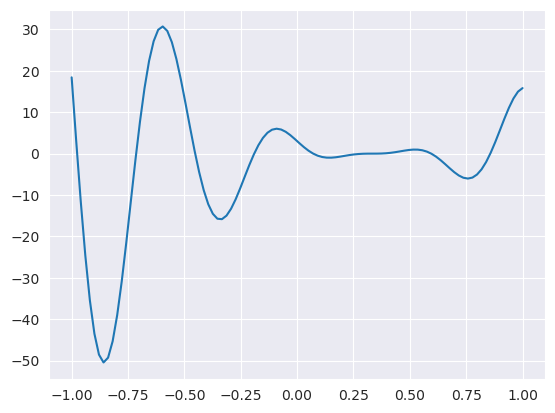

In [3]:
# definition of Forrester function
def forrester(z):
    return (6*z-2)**2*np.sin(12*z-4)

plt.plot(np.linspace(-1, 1, 100), forrester(np.linspace(-1, 1, 100)))

You define here a latin hypercube sampling and a gaussian meta model for regression.

In [4]:
# Definition of initial DoE
# To generate initial DoE, we use the function 'LHS' of the package pyDOE
# The first argument is the dimension of the design vector, the second is the number of points in the DoE
z_init = lhs(1,10)
bounds = np.array([[0.,1]])

f_z = forrester(z_init*(bounds[:,1] - bounds[:,0]) + bounds[:,0])

k = GPy.kern.RBF(1, ARD = True)
GP = GPy.models.GPRegression(z_init, f_z, k)

print("Before Optimization, the likelihood of the noise is ", GP.likelihood.variance.values.item())
print("Before Optimization, the kernel's parameters are\n", k)
print("\n")

#Find the right parameter of the gaussian model.
GP.optimize()

print("After Optimization, the likelihood of the noise is ", GP.likelihood.variance.values.item())
print("After Optimization, the kernel's parameters are \n", k)

Before Optimization, the likelihood of the noise is  1.0
Before Optimization, the kernel's parameters are
   rbf.         |  value  |  constraints  |  priors
  variance     |    1.0  |      +ve      |        
  lengthscale  |    1.0  |      +ve      |        


After Optimization, the likelihood of the noise is  20.663318390672387
After Optimization, the kernel's parameters are 
   rbf.         |                  value  |  constraints  |  priors
  variance     |      9.231355193347776  |      +ve      |        
  lengthscale  |  0.0015836285396893816  |      +ve      |        


As you can see, the noise variance is very high, making the inference very unsure. If we want to suppress the effect of the variance, one has to set it small, and prevent the optimizer to tune it. This is the objective of the commands <code>GP.likelihood.variance = 1e-10</code> and <code>GP.likelihood.variance.fix()</code> below. It fixes $\sigma$ to $10^{-10}$.


To understand the GP class, see [here](https://gpy.readthedocs.io/en/deploy/GPy.core.html#GPy.core.gp.GP.optimize).

For the hyperparameter's optimization, see [here](https://gpy.readthedocs.io/en/deploy/GPy.core.html#GPy.core.gp.GP.optimize). Apparently, the algorithm employed by default is L-BFGS.

For likelihood object, see [here](https://gpy.readthedocs.io/en/deploy/GPy.likelihoods.html#GPy.likelihoods.likelihood.Likelihood). Observe that we do not find back the variance attribute.

In [17]:
# Definition of initial DoE
# To generate initial DoE, we use the function 'LHS' of the package pyDOE
# The first argument is the dimension of the design vector, the second is the number of points in the DoE
z_init = lhs(1,4)
bounds = np.array([[0.,1]])

f_z = forrester(z_init*(bounds[:,1] - bounds[:,0]) + bounds[:,0])

k = GPy.kern.RBF(1, ARD = True)

GP = GPy.models.GPRegression(z_init, f_z, k)

#You fix here the noise variance injected in the measure.
GP.likelihood.variance = 1e-10
GP.likelihood.variance.fix()

#Optimize the model hyperparameters
GP.optimize()

print("After Optimization, the likelihood of the noise is ", GP.likelihood.variance.values.item())

After Optimization, the likelihood of the noise is  1e-10


As expected, the realizations all takes the same value at the colocation points.

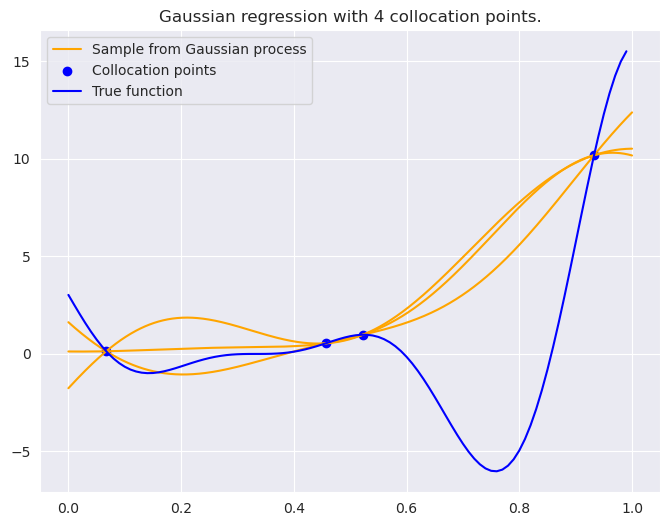

In [28]:
GP.posterior_samples(z_init)
n=3
X = np.linspace(bounds[:,0], bounds[:,1], 1000)
res = GP.posterior_samples(X, size=n)

plt.figure(figsize=(8,6))

for i in range(n):
    if i==0:
        plt.plot(X.flatten(), res[:,0,i].flatten(), label='Sample from Gaussian process', color="orange")
    else:
        plt.plot(X.flatten(), res[:,0,i].flatten(), color="orange")
plt.scatter(z_init.flatten(), f_z.flatten(), color = 'blue', label='Collocation points')
z=np.arange(0, 1, .01)
plt.plot(z, forrester(z), label="True function", color="Blue")
plt.legend()
plt.title("Gaussian regression with 4 collocation points.")
plt.show()

Now, let's do the same but with more points.

After Optimization, the likelihood of the noise is  1e-10


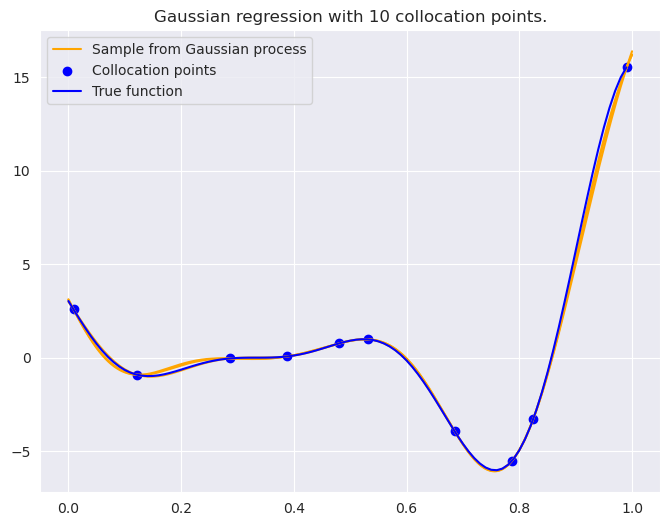

In [ ]:
# Definition of initial DoE
# To generate initial DoE, we use the function 'LHS' of the package pyDOE
# The first argument is the dimension of the design vector, the second is the number of points in the DoE
z_init = lhs(1,10)
bounds = np.array([[0.,1]])

f_z = forrester(z_init*(bounds[:,1] - bounds[:,0]) + bounds[:,0])

k = GPy.kern.RBF(input_dim=1, variance=1, ARD = True)

GP = GPy.models.GPRegression(z_init, f_z, k)

#You fix here the noise variance injected in the measure.
GP.likelihood.variance = 1e-10
GP.likelihood.variance.fix()

#Optimize the model hyperparameters
GP.optimize()

print("After Optimization, the likelihood of the noise is ", GP.likelihood.variance.values.item())

GP.posterior_samples(z_init)
n=3
X = np.linspace(bounds[:,0], bounds[:,1], 1000)
res = GP.posterior_samples(X, size=n)

plt.figure(figsize=(8,6))

for i in range(n):
    if i==0:
        plt.plot(X.flatten(), res[:,0,i].flatten(), label='Sample from Gaussian process', color="orange")
    else:
        plt.plot(X.flatten(), res[:,0,i].flatten(), color="orange")
plt.scatter(z_init.flatten(), f_z.flatten(), color = 'blue', label='Collocation points')
z=np.arange(0, 1, .01)
plt.plot(z, forrester(z), label="True function", color="Blue")
plt.legend()
plt.title("Gaussian regression with 10 collocation points.")
plt.show()

You can also use the <code>predict</code> method to extract the parameters (mean and variance) of the posterior distribution at any chosen points.

As expected, at the collocation points, the uncertainty is very small. Indeed, the process is constrained to take specified values at this points by conditioning. It represents measure data, and should be taken account when updating a model.

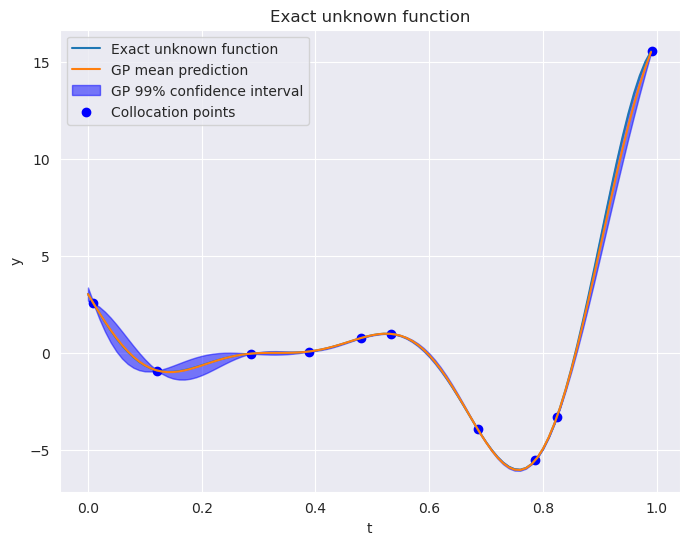

In [44]:
t=np.arange(0,1,0.01)
y=forrester(t)
mean, var = GP.predict(t[...,None])

y_pred_sup=mean + 3*np.sqrt(var)
y_pred_inf=mean - 3*np.sqrt(var)

plt.figure(figsize=(8,6))
plt.plot(t,y,label="Exact unknown function")
plt.plot(t,mean,label="GP mean prediction")
plt.fill_between(np.reshape(t,(len(t),)), np.reshape(y_pred_inf,(len(y_pred_inf),)), np.reshape(y_pred_sup,(len(y_pred_sup),)),color = 'blue',alpha = 0.5, label = 'GP 99% confidence interval')
plt.scatter(z_init.flatten(), f_z.flatten(), color = 'blue', label='Collocation points')
plt.xlabel("t")
plt.ylabel("y")
plt.title("Exact unknown function")
plt.legend()
display(HTML("""<style>#output-body {display: flex; align-items: center;justify-content: center;}</style>"""))  #to plot at the center of the page

The fun is you can apply gaussian process to function in $\mathbb{R}^d$, $d>1$. Assume you want to perturbate a circle to have a variety of shape, which look close to a circle but are not exactly one.



## Perturbation of the circle: an example in 2D

The goal here is to create a Gaussian process which is the perturbation of a circle. Therefore, the goal is to create a gaussian process $f: [0, 2\pi[ \longrightarrow \mathbb{R}^2$, whose colocation points are located on an unitary circle.

Before optimization, the kernel parameters are
   rbf.         |  value  |  constraints  |  priors
  variance     |    1.0  |      +ve      |        
  lengthscale  |    1.0  |      +ve      |        
After optimization, the kernel parameters are
   rbf.         |               value  |  constraints  |  priors
  variance     |  0.8636283275403569  |      +ve      |        
  lengthscale  |   1.693983105144819  |      +ve      |        


{'dataplot': [<matplotlib.collections.PathCollection at 0x71bdb84b8b00>,
 'gpmean': [[<matplotlib.lines.Line2D at 0x71bdb84b9ac0>,
 'gpconfidence': [<matplotlib.collections.PolyCollection at 0x71bdb90b4b00>,
  <matplotlib.collections.PolyCollection at 0x71bdb8ee8a10>]}

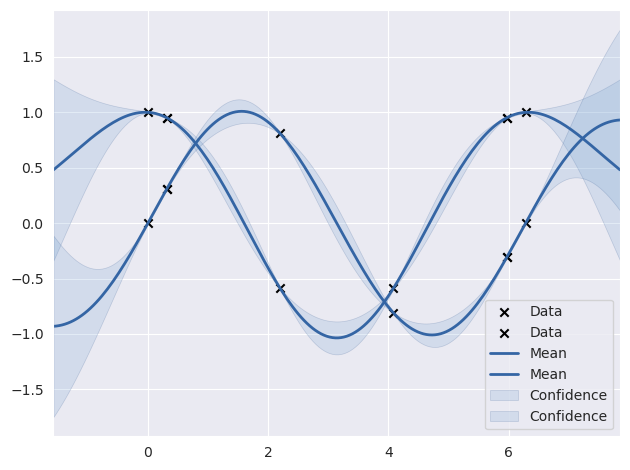

In [45]:
Theta_collocation = np.concatenate((np.linspace(np.pi/10, 2*np.pi - np.pi/10, 4)[:,None], np.linspace(0, np.pi/10, 2)[:,None], np.linspace(2*np.pi - np.pi/10, 2*np.pi, 2)[:,None]))
N_SAMPLE = 3
X = np.concatenate((np.cos(Theta_collocation), np.sin(Theta_collocation)), axis = -1)
k = GPy.kern.RBF(1)
print("Before optimization, the kernel parameters are\n", k)
GP_circle = GPy.models.GPRegression(Theta_collocation, X, k)
GP_circle.likelihood.variance = .00001
GP_circle.likelihood.fix()
GP_circle.optimize()

print("After optimization, the kernel parameters are\n", k)

GP_circle.plot()

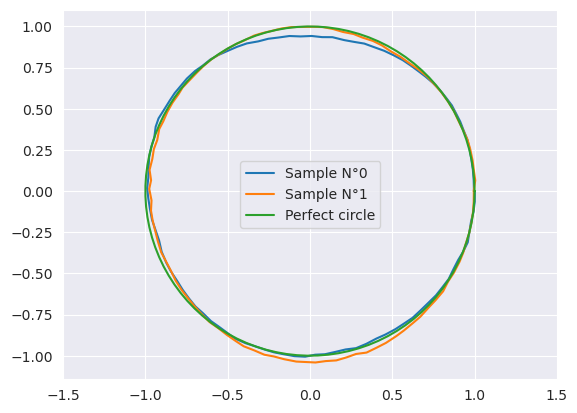

In [50]:
Theta = np.linspace(0, 2*np.pi, 100)[:,None]
post_x, post_y = np.transpose(GP_circle.posterior_samples(Theta, size=N_SAMPLE), axes = (1, 2, 0))
for i in range(2):
    plt.plot(post_x[i], post_y[i], label=f"Sample N°{i}")
    plt.axis("equal")

plt.plot(np.cos(Theta), np.sin(Theta), label="Perfect circle")
plt.legend()
plt.show()

One could also do data augmentation by rotating the circle via a rotation matrix.